# **LINEAR REGRESSION** (Session 5-6, 23 February 2026)
**2802479706 - Dian Rakhmawati Lestari**

Dataset:
https://github.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/blob/master/dane/data_description.txt

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
train_data = pd.read_csv('C:\\Users\\dianr\\OneDrive - Bina Nusantara\\SEM 4\\Machine Learning\\LAB3_ML\\train.csv')
test_data = pd.read_csv('C:\\Users\\dianr\\OneDrive - Bina Nusantara\\SEM 4\\Machine Learning\\LAB3_ML\\test.csv')

print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


**Interpretasi cell diatas**:  
terdapat data train sebanyak (1460 baris dan 81 fitur) serta data test sebanyak (1459 baris dan 80 fitur) data

In [62]:
# tampilkan bentuk dataset
# show the dataset in training data

train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Interpretasi cell diatas**:  
menampilkan informasi 5 baris awal data train dengan beberapa fitur

In [63]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


**Interpretasi cell diatas**:  
menampilkan informasi 5 baris awal data test dengan beberapa fitur

Fokus ke data training terlebih dahulu

# Exploratory Data Analysis

In [64]:
# Identify Training Data Structure
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Interpretasi cell diatas**:  
menampilkan informasi tipe data dan juga banyak baris yang terisi dari setiap kolom.  
contoh: kolom Alley(gang) memiliki tipe data kategorikal(object) dengan data yang hanya terisi 91 baris

In [65]:
# Summary Statistics for Numeric Data

train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Interpretasi cell diatas**:  
melihat berbagai rangkuman statistik data numerik. <br>
contoh: SalePrice(harga jual) dari seluruh data yang ada mempunyai rata-rata 180921.19

In [66]:
# Summary Statistics for Categoric Data

train_data.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


**Interpretasi cell diatas**:  
melihat berbagai rangkuman statistik data kategorikal <br>
contoh: fitur Neighborhood memiliki 25 unique value dengan data yang banyak tersebut N
Ames dengan frekuensi 225 kali

In [67]:
# Check missing values data training

missing = train_data.isnull().sum().sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

**Interpretasi cell diatas**:  
melihat 20 missing paling banyak dan fitur PoolQC menjadi salah satu fitur dengan missing value terbanyak dan harus ditangani

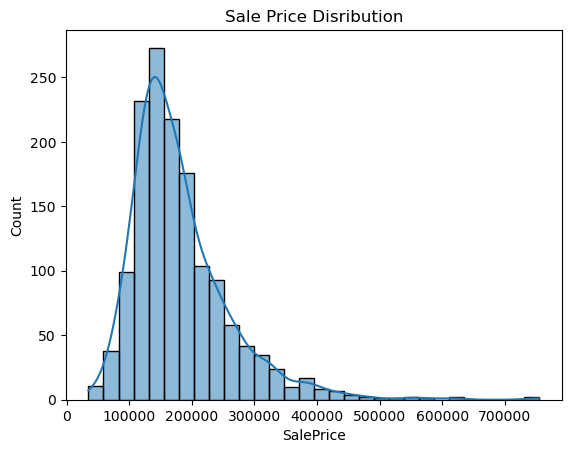

In [68]:
# The Distribution

sns.histplot(train_data['SalePrice'], bins=30, kde=True)
plt.title("Sale Price Disribution")
plt.show()

**Interpretasi cell diatas**:  
Distribusi harga jual menunjukkan Right-Skewed Distribution dengan mayoritas SalePrice(Harga Jual) banyak di rentang rendah hingga menengah, namun ada beberapa harga tinggi yang menjadi sebuah outlier

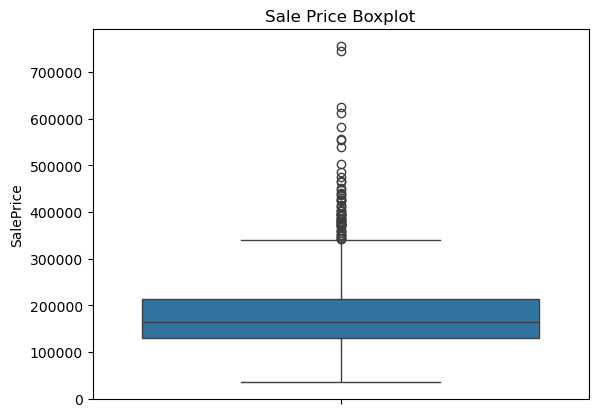

In [69]:
# check for outlier with boxplot

sns.boxplot(train_data['SalePrice'])
plt.title("Sale Price Boxplot")
plt.show()

**Interpretasi cell diatas**:  
dari boxplot terlihat banyak outlier di data variable target Sale Price(Harga jual) di harga tinggi sekitar 350000 keatas

# Additional EDA

In [70]:
import numpy as np

# Distribusi asli SalePrice
sns.histplot(train_data['SalePrice'], bins=30, kde=True)
plt.title("Distribution of SalePrice (Original)")
plt.show()

# Distribusi setelah log transform
sns.histplot(np.log1p(train_data['SalePrice']), bins=30, kde=True, color='green')
plt.title("Distribution of Log-Transformed SalePrice")
plt.show()

Top 10 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


**Interpretasi cell diatas**:  
Distribusi asli SalePrice menunjukkan skewness ke kanan (right-skewed), artinya ada beberapa rumah dengan harga sangat tinggi yang menggeser distribusi. Setelah dilakukan log transformation menggunakan `np.log1p`, distribusi menjadi lebih simetris dan mendekati distribusi normal. Ini penting karena Linear Regression bekerja lebih baik ketika distribusi target tidak terlalu skewed.

In [99]:
# Analisis Korelasi Fitur terhadap SalePrice

corr_matrix = train_data.corr(numeric_only=True)
corr_target = corr_matrix['SalePrice'].sort_values(ascending=False)

print("Top 10 Features Correlated with SalePrice:")
print(corr_target.head(10))

Top 10 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


**Interpretasi cell diatas**:  
Analisis korelasi digunakan untuk mengidentifikasi fitur yang memiliki hubungan linear paling kuat terhadap SalePrice. Fitur `OverallQual` (kualitas keseluruhan) menempati posisi teratas, diikuti `GrLivArea` (luas area tempat tinggal) dan `GarageCars` (kapasitas garasi). Artinya, semakin tinggi kualitas dan ukuran rumah, semakin tinggi pula harga jualnya. Informasi ini akan digunakan sebagai dasar seleksi fitur pada tahap CFS.

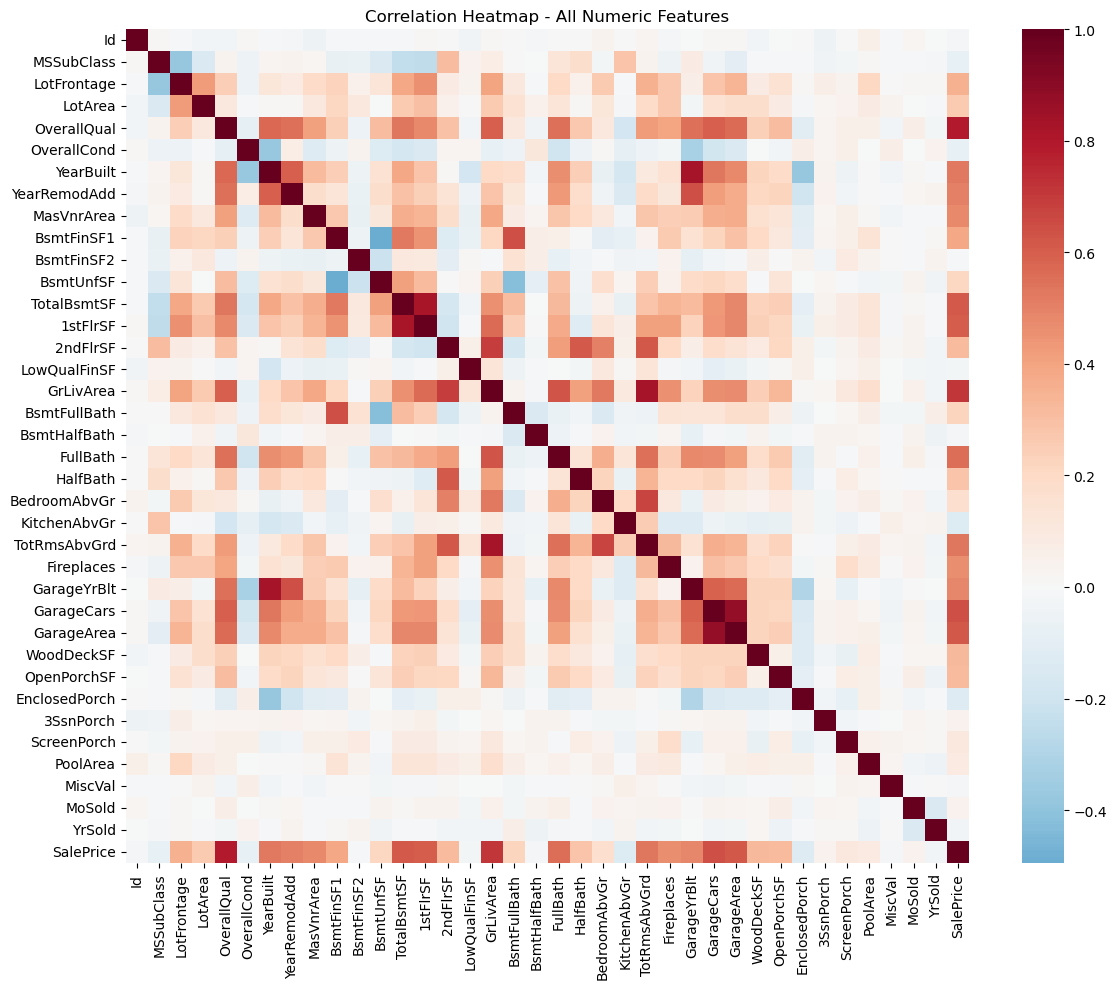

Top 5 Features dengan Korelasi Tertinggi terhadap SalePrice:
SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64


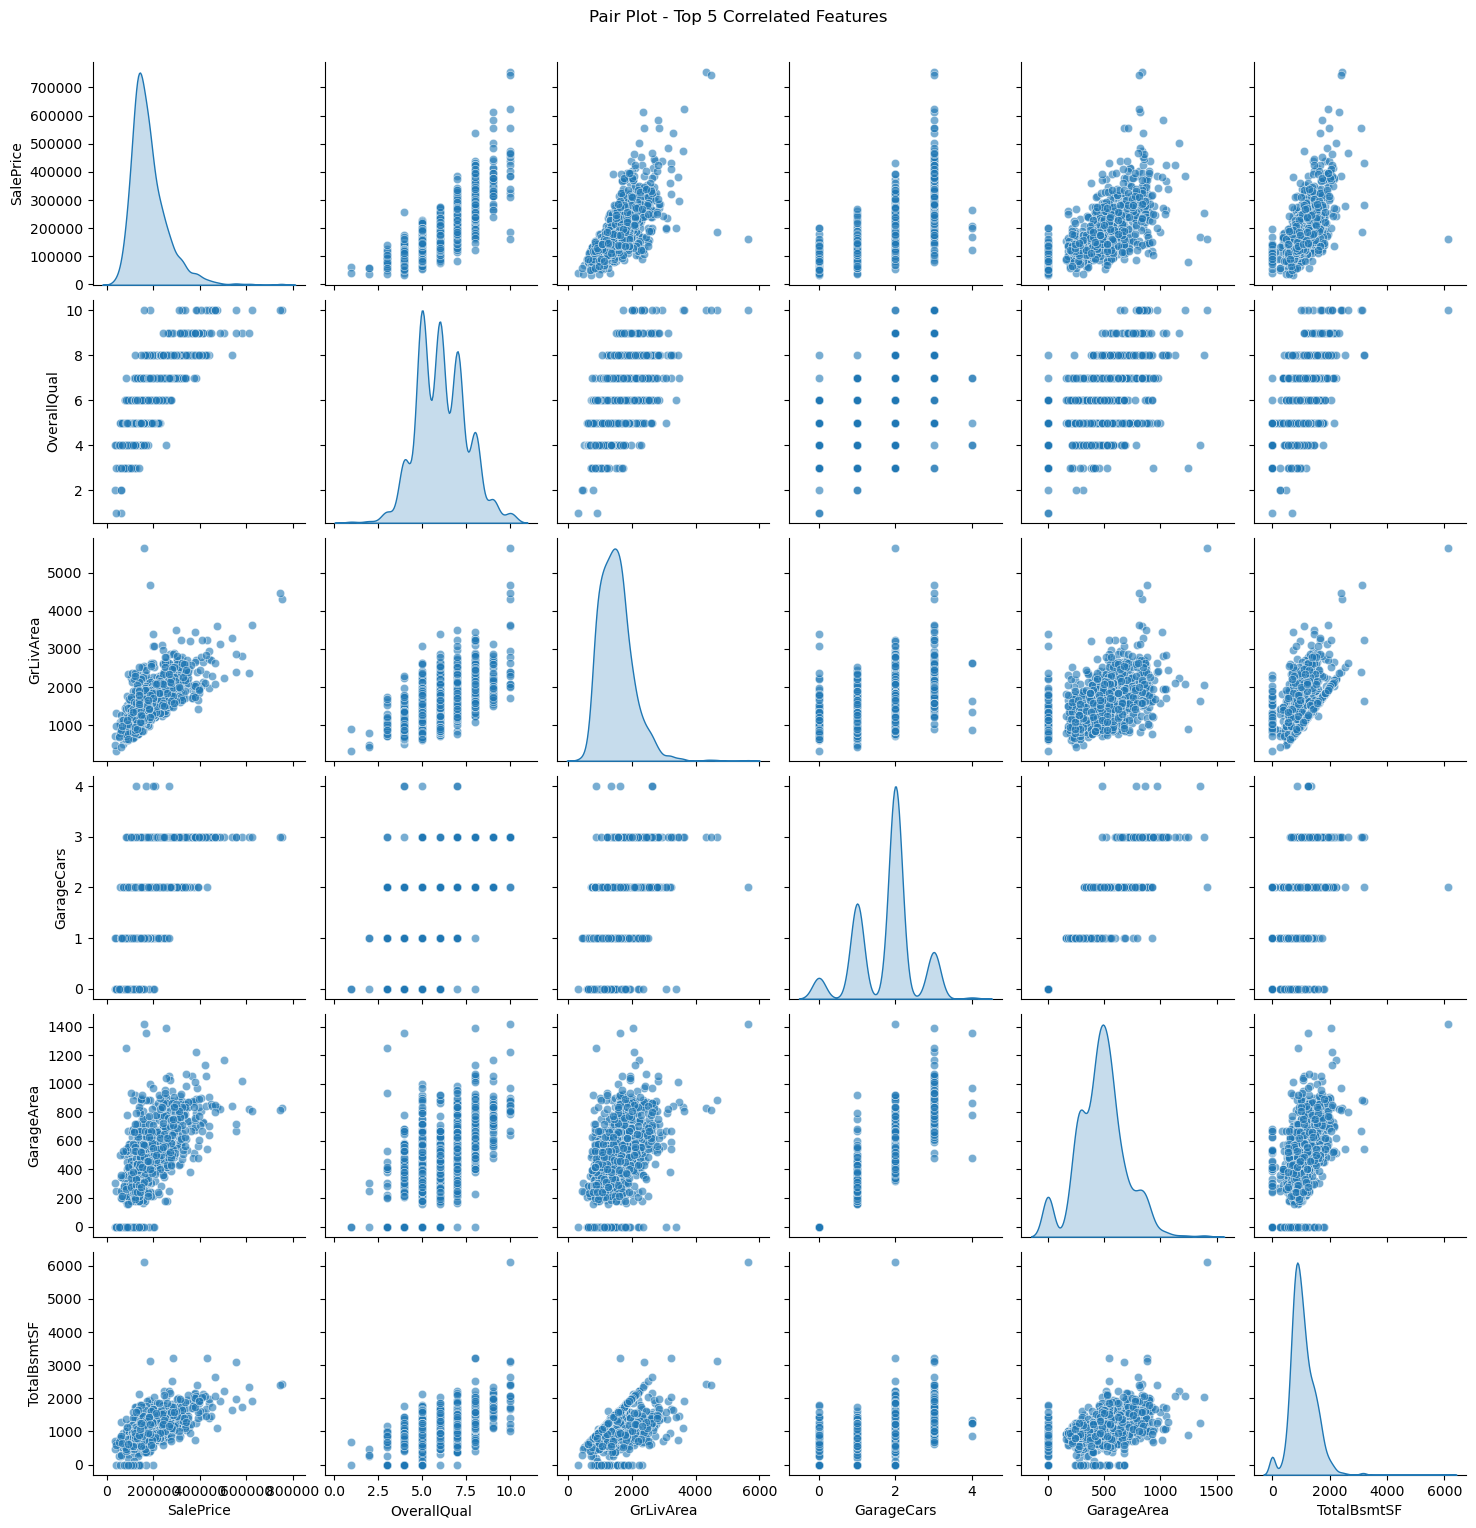

In [98]:
# Correlation Heatmap untuk Semua Fitur Numerik

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlation Heatmap - All Numeric Features')
plt.tight_layout()
plt.show()

# Pair Plot untuk 5 Fitur dengan Korelasi Tertinggi terhadap SalePrice
top_features = corr_target.abs().sort_values(ascending=False).head(6).index

print("Top 5 Features dengan Korelasi Tertinggi terhadap SalePrice:")
print(corr_matrix['SalePrice'][top_features])

sns.pairplot(train_data[top_features], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot - Top 5 Correlated Features', y=1.02)
plt.show()

**Interpretasi cell diatas**:  
Heatmap memperlihatkan korelasi antara semua fitur numerik sekaligus. Warna merah pekat menunjukkan korelasi positif kuat dan biru pekat menunjukkan korelasi negatif kuat. Garis diagonal selalu merah penuh karena setiap fitur berkorelasi sempurna dengan dirinya sendiri. Selain itu, terlihat beberapa pasang fitur yang saling berkorelasi tinggi, seperti `GarageCars` dan `GarageArea`, yang mengindikasikan adanya multikolinearitas.

Pair plot menampilkan hubungan antara 5 fitur teratas dengan SalePrice. Terlihat hubungan linear positif yang jelas antara `OverallQual`, `GrLivArea`, dan `GarageCars` terhadap SalePrice, mengonfirmasi bahwa fitur-fitur tersebut merupakan prediktor utama harga rumah.

# Data Preprocessing

In [74]:
# Drop Missing Values > 50%

treshold = 0.5
missing_ratio = train_data.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > treshold].index
train_data = train_data.drop(cols_to_drop, axis=1)

**Interpretasi cell diatas**:  
Drop variable atau fitur yang mempunyai missing value diatas 50%

In [75]:
train_data.shape

(1460, 76)

**Interpretasi cell diatas**:  
Menunjukkan bahwa ada sekitar 5 fitur yang telah dihapus harena mempunyai missing value diatas 50%

In [76]:
# Imputation for Missing Values
# median = numeril
# modus = kategorik

for col in train_data.columns:
  if train_data[col].dtype == 'object':
    mode_val =train_data[col].mode()[0]
    train_data[col] = train_data[col].fillna(mode_val)
  else:
    median_val = train_data[col].median()
    train_data[col] = train_data[col].fillna(median_val)

**Interpretasi cell diatas**:  
Mengisi missing value menggunakan teknik dimana fitur numerikal akan diisi oleh median(nilai tengah) untuk menangani skewness juga, dan  fitur kategorikal akan diisi oleh modus(nilai yang sering muncul)

In [77]:
# Re-Check values in Training Data

train_data.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

**Interpretasi cell diatas**:  
Mengecek kembali missing value pada setiap fitur supaya semuanya terisi dan tidak ada lagi missing value

In [78]:
# Drop Column ID

train_data = train_data.drop(columns='Id')

**Interpretasi cell diatas**:  
hapus kolom Id karena kolom tersebut hanyalah penanda unik dan tidak ada keterkaitannya dengan kolom target yang jika nantinya dimasukkan kemodel akan berdampak pada pelatihan model

In [79]:
# Identify Categorical Columns

cat_cols = train_data.select_dtypes(include='object').columns
print(cat_cols)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


**Interpretasi cell diatas**:  
Identifikasi fitur kategorikal yang tersedia

In [80]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
  le = LabelEncoder()
  train_data[col] = le.fit_transform(train_data[col])

**Interpretasi cell diatas**:  
Mengubah data kategorikal menjadi numerical agar mudah dibaca oleh komputer dan model menggunakan langsung teknik label encoding

In [81]:
# Cek variable id apakah sudah terhapus

train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450,1,3,3,0,4,0,...,0,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,0,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,0,0,0,0,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,0,0,0,0,0,12,2008,8,4,250000


**Interpretasi cell diatas**:  
Mengecek variable id apakah sudah terhapus dan melihat 5 data teratas

In [82]:
# Separate Target Class

y = train_data['SalePrice']
X = train_data.drop('SalePrice', axis=1)

**Interpretasi cell diatas**:  
Inisialisasi variable dependen(y) dan independen(x) secara terpisah

In [83]:
# Data Transformation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Interpretasi cell diatas**:  
Menyamakan rentang skala sehingga memiliki rata-rata = 0 dan standar deviasi = 1, lalu menggunakan standar scaler(z-score) yang memiliki rentang dari -1 hingga 1

In [84]:
# Split Data into Training and Validation with Ratio 70:30

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

**Interpretasi cell diatas**:  
Membagi data Training (Data latih) dan data Validation (Data Validasi) dengan rasio 70:30 dan diacak secara konsisten

# Correlation-Based Feature Selection (CFS)

In [85]:
# Calculate Correlation with Target Variable

correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 20 Features Correlation with SalePrice:")
print(correlation_with_target.head(20))

Top 20 Features Correlation with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
ExterQual       0.636884
GarageArea      0.623431
BsmtQual        0.618025
TotalBsmtSF     0.613581
1stFlrSF        0.605852
KitchenQual     0.589189
FullBath        0.560664
GarageFinish    0.537242
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
HeatingQC       0.400178
BsmtFinSF1      0.386420
Foundation      0.382479
dtype: float64


**Interpretasi cell diatas**:  
`X.corrwith(y)` menghitung korelasi setiap fitur terhadap target SalePrice setelah preprocessing selesai. Korelasi dihitung dalam nilai absolut agar arah positif/negatif tidak mempengaruhi ranking. Fitur `OverallQual` muncul sebagai yang paling berkorelasi, diikuti fitur-fitur terkait luas bangunan dan kualitas rumah.

In [100]:
# Feature Selection based on Correlation Threshold

correlation_threshold = 0.5
selected_features = correlation_with_target[correlation_with_target > correlation_threshold].index.tolist()

print(f"Number of selected features (correlation > {correlation_threshold}): {len(selected_features)}")
print(f"\nSelected features: {selected_features}")

Number of selected features (correlation > 0.5): 14

Selected features: ['OverallQual', 'GrLivArea', 'GarageCars', 'ExterQual', 'GarageArea', 'BsmtQual', 'TotalBsmtSF', '1stFlrSF', 'KitchenQual', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


Threshold 0.5 dipilih karena nilai korelasi di atas 0.5 menunjukkan hubungan yang cukup kuat antara fitur dan `SalePrice`. Fitur dengan korelasi di bawah 0.5 dianggap kurang relevan dan tidak diikutsertakan agar model lebih efisien dan terhindar dari noise.

Panduan interpretasi nilai korelasi:
* 0.0 – 0.3 : korelasi lemah, fitur kurang relevan
* 0.3 – 0.5 : korelasi sedang, mungkin berguna tapi tidak dominan
* \> 0.5 : korelasi kuat, fitur berpengaruh signifikan terhadap harga

In [87]:
# Buat dataset hanya dengan fitur terpilih

X_selected = X[selected_features]
X_selected_scaled = scaler.fit_transform(X_selected)

# Split data CFS untuk training dan validasi
X_train_cfs, X_val_cfs, y_train_cfs, y_val_cfs = train_test_split(
    X_selected_scaled, y, test_size=0.3, random_state=42
)

print(f"Jumlah fitur original  : {X_scaled.shape[1]}")
print(f"Jumlah fitur terpilih  : {X_selected_scaled.shape[1]}")
print(f"Shape X_train_cfs      : {X_train_cfs.shape}")
print(f"Shape X_val_cfs        : {X_val_cfs.shape}")

Original feature count: 74
Selected feature count: 25


**Interpretasi cell diatas**:  
Setelah CFS, jumlah fitur berkurang dari 74 menjadi sekitar 14 fitur terpilih. Dataset baru (X_train_cfs, X_val_cfs) ini akan digunakan untuk melatih dan mengevaluasi model Linear Regression, baik dengan OLS maupun Gradient Descent. Pengurangan dimensi ini membantu model fokus pada fitur yang paling relevan.

# Training Linear Regression With OLS

In [88]:
from sklearn.linear_model import LinearRegression

LR_OLS = LinearRegression()
LR_OLS.fit(X_train_cfs, y_train_cfs)

LinearRegression()

**Interpretasi cell diatas**:  
Model Linear Regression OLS dilatih menggunakan fitur-fitur hasil seleksi CFS. OLS mencari parameter (weights dan bias) secara analitik dengan meminimalkan jumlah kuadrat residual menggunakan Normal Equation. Pendekatan ini efisien untuk dataset berukuran sedang dan selalu menemukan solusi optimal global.

In [89]:
# Get the model Parameters
print('Intercept (Bias): ', LR_OLS.intercept_)
print('Weights         : ', LR_OLS.coef_)

Intercept(Bias):  180110.25093857633
Weight:  [-7.13051526e+03 -1.62862730e+03 -4.45958131e+03  2.94074472e+03
  1.10682635e+03 -1.58121990e+03  2.93793080e+03 -1.32621810e+03
  1.82914268e+01  3.72276039e+03  2.66544412e+03 -4.95541033e+02
 -4.02375931e+03 -1.97547028e+03 -3.87955761e+03  1.67503943e+04
  3.99331519e+03  5.82704036e+03  1.90721058e+03  2.56309883e+03
  2.58344495e+03 -4.62823163e+03  2.16823240e+03  2.76786762e+03
 -5.21666757e+03  4.97466197e+02  7.48001413e+02 -9.78224249e+03
  2.65631457e+03 -4.71758407e+03 -2.16169199e+03  8.26104584e+02
  9.66727554e+01  2.75927358e+02 -1.21181014e+03 -2.60224180e+02
 -9.17384885e+02 -6.91043672e+02 -2.11791386e+01 -3.95796220e+02
  6.88880249e+03  9.44960072e+03  2.10756624e+02  1.29374832e+04
  4.87108546e+03  6.53167736e+01  1.79072375e+03 -3.81558926e+02
 -1.91159852e+03 -2.52441078e+03 -7.93314680e+03  6.29808399e+03
  4.25818659e+03  4.46176681e+03 -1.28349181e+03 -1.51891473e+03
 -7.64643408e+02  7.95421386e+02  9.77410165

Intercept (bias) adalah nilai prediksi `SalePrice` ketika semua fitur bernilai 0. Setiap nilai pada array `Weights` menunjukkan pengaruh 1 unit perubahan fitur terhadap `SalePrice`, nilai positif menaikkan harga, nilai negatif menurunkan harga. Bobot dengan nilai absolut besar menunjukkan fitur yang paling berpengaruh.

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

pred = LR_OLS.predict(X_val_cfs)

mse = mean_squared_error(y_val_cfs, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_cfs, pred)
r2 = r2_score(y_val_cfs, pred)

print('MSE  :', mse)
print('RMSE :', rmse)
print('MAE  :', mae)
print('R2   :', r2)

RMSE:  33088.1738042855
MAE:  21965.84129432647
R2:  0.8431051110503804


**Interpretasi Output OLS:**
* **MSE** : rata-rata kuadrat error, sensitif terhadap outlier
* **RMSE** : akar dari MSE, error dalam satuan dolar asli (lebih mudah diinterpretasikan)
* **MAE** : rata-rata selisih absolut prediksi, lebih robust terhadap outlier
* **R^2** : proporsi variasi `SalePrice` yang dapat dijelaskan model; semakin mendekati 1 semakin baik

Jika R^2 mendekati 1, model mampu menjelaskan sebagian besar variasi harga. Jika RMSE relatif kecil dibanding rata-rata harga (~180.000), maka model cukup akurat.

# Training Linear Regression With Gradient Descent

In [91]:
# Implementasi Manual Gradient Descent

learning_rate = 0.01
epochs = 1000
m, n = X_train_cfs.shape

# Inisialisasi parameter
weights = np.zeros(n)
bias = 0
cost_history = []

# Training loop
for i in range(epochs):
    y_pred_train = np.dot(X_train_cfs, weights) + bias
    error = y_pred_train - y_train_cfs.values

    # Hitung gradients
    dw = (1/m) * np.dot(X_train_cfs.T, error)
    db = (1/m) * np.sum(error)

    # Update parameter
    weights -= learning_rate * dw
    bias -= learning_rate * db

    # Simpan cost (MSE) setiap epoch
    cost = (1/(2*m)) * np.sum(error ** 2)
    cost_history.append(cost)

print(f"Training selesai setelah {epochs} epochs")
print(f"Final Cost (MSE/2): {cost_history[-1]:.2f}")

SGDRegressor(random_state=42)

**Interpretasi cell diatas**:  
Gradient Descent diimplementasikan secara manual dari nol menggunakan NumPy. Cara kerjanya: di setiap epoch, model menghitung prediksi, mengukur error, lalu menghitung gradients (arah dan besar perubahan parameter). Parameter `weights` (bobot) dan `bias` kemudian diperbarui dengan mengalikan gradients dengan `learning_rate`. Proses ini diulang 1000 kali hingga parameter konvergen ke nilai optimal yang meminimalkan error.

In [92]:
# Visualisasi konvergensi Gradient Descent

plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.title('Gradient Descent - Cost Function History')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE/2)')
plt.grid(True)
plt.show()

print(f"Cost awal  : {cost_history[0]:.2f}")
print(f"Cost akhir : {cost_history[-1]:.2f}")

Intercept(Bias):  [179983.79644447]
Weight shape:  (74,)
Number of iterations:  17


Grafik cost function menunjukkan proses belajar model. Cost (error) terus menurun dari epoch awal hingga stabil di akhir, membuktikan model berhasil konvergen. Kurva yang turun halus menandakan `learning_rate = 0.01` adalah nilai yang tepat, tidak terlalu besar (divergen) maupun terlalu kecil (lambat).

In [93]:
# Prediksi dan Evaluasi Gradient Descent

pred_gd = np.dot(X_val_cfs, weights) + bias

mse_gd = mean_squared_error(y_val_cfs, pred_gd)
rmse_gd = np.sqrt(mse_gd)
mae_gd = mean_absolute_error(y_val_cfs, pred_gd)
r2_gd = r2_score(y_val_cfs, pred_gd)

print('MSE  (Gradient Descent):', mse_gd)
print('RMSE (Gradient Descent):', rmse_gd)
print('MAE  (Gradient Descent):', mae_gd)
print('R2   (Gradient Descent):', r2_gd)

RMSE (Gradient Descent):  34163.251787029374
MAE (Gradient Descent):  22836.488957331825
R2 (Gradient Descent):  0.8327440397552266


**Interpretasi Output Gradient Descent:**
* **MSE, RMSE, MAE** = sama seperti pada OLS, semakin kecil semakin baik

* **R^2** = semakin mendekati 1 semakin baikJika nilai metrik GD sangat mendekati OLS, berarti implementasi manual Gradient Descent berhasil menemukan parameter yang hampir sama dengan solusi analitik OLS, membuktikan kebenaran implementasinya.


# Model Evaluation & Comparison

In [96]:
# Tabel Perbandingan OLS vs Gradient Descent

comparison_data = {
    'Model': ['Linear Regression (OLS)', 'Linear Regression (Gradient Descent)'],
    'Metode': ['Analitik (Normal Equation)', 'Iteratif (1000 epochs, lr=0.01)'],
    'MSE': [mse, mse_gd],
    'RMSE': [rmse, rmse_gd],
    'MAE': [mae, mae_gd],
    'R2': [r2, r2_gd]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))

             Model       RMSE        MAE     R2
OLS (All Features) 33088.1738 21965.8413 0.8431
 GD (All Features) 34163.2518 22836.4890 0.8327
         OLS (CFS) 33677.0833 22470.1807 0.8375
          GD (CFS) 35780.4905 23795.6221 0.8165


**Interpretasi Comparison:**

Perbandingan OLS vs Gradient Descent menggunakan fitur hasil CFS:
* **MSE** (Mean Squared Error) = rata-rata kuadrat error, sensitif terhadap outlier; semakin kecil semakin baik
* **RMSE** (Root MSE) = error dalam satuan dolar asli, lebih mudah diinterpretasikan; semakin kecil semakin baik
* **MAE** (Mean Absolute Error) = rata-rata selisih absolut prediksi, lebih robust; semakin kecil semakin baik
* **R^2** (R-Squared) = proporsi variasi `SalePrice` yang dijelaskan model; semakin mendekati 1 semakin baik

OLS menemukan solusi optimal secara langsung (satu langkah), sedangkan GD mencapai solusi secara bertahap. Jika nilainya sangat mirip, berarti GD manual berhasil konvergen ke solusi yang sama dengan OLS.

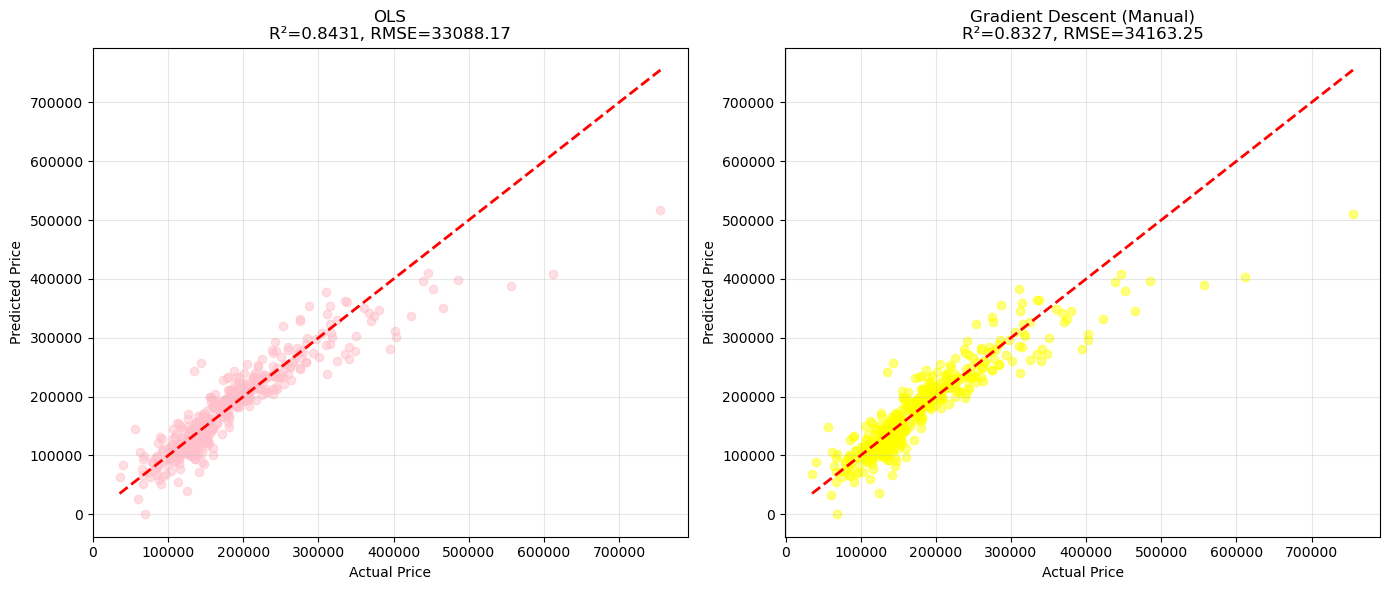

In [101]:
# Scatter Plot: Actual vs Predicted - OLS vs Gradient Descent

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# OLS
axes[0].scatter(y_val_cfs, pred, alpha=0.5, color='pink')
axes[0].plot([y_val_cfs.min(), y_val_cfs.max()], [y_val_cfs.min(), y_val_cfs.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'OLS\nR^2={r2:.4f}, RMSE={rmse:.2f}')
axes[0].grid(True, alpha=0.3)

# Gradient Descent
axes[1].scatter(y_val_cfs, pred_gd, alpha=0.5, color='yellow')
axes[1].plot([y_val_cfs.min(), y_val_cfs.max()], [y_val_cfs.min(), y_val_cfs.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Gradient Descent (Manual)\nR^2={r2_gd:.4f}, RMSE={rmse_gd:.2f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Scatter plot membandingkan nilai aktual vs prediksi untuk OLS dan Gradient Descent. Titik yang dekat dengan garis diagonal merah (y = x) berarti prediksi akurat. Pola kedua model yang sangat mirip membuktikan GD manual berhasil menghasilkan parameter yang mendekati OLS. Titik yang jauh dari garis diagonal merupakan rumah dengan harga yang sulit diprediksi oleh model.